In [79]:
import kagglehub
import shutil
import os

# 1. Download the latest version to the default cache
cache_path = kagglehub.dataset_download("camnugent/california-housing-prices")
print("Downloaded to cache at:", cache_path)

# 2. Define your specific destination folder
target_folder = "."

# 3. Copy the contents from the cache to your target folder
shutil.copytree(cache_path, target_folder, dirs_exist_ok=True)

print(f"Dataset is now ready directly in: {target_folder}") 

Downloaded to cache at: C:\Users\Annie\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1
Dataset is now ready directly in: .


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
data = pd.read_csv("housing.csv")

In [82]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [83]:
# light EDA before splitting, deep EDA will be done on the training set only to avoid data leakage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [84]:
data.dropna(inplace=True) # inplace=True to modify the original DataFrame
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [85]:
# splitting the dataset into features and target variable
from sklearn.model_selection import train_test_split

X = data.drop(["median_house_value"], axis=1) # axis=1 means drop column, axis=0 means drop row
y = data["median_house_value"]

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [87]:
# join the training features and target variable for EDA
train_data = X_train.join(y_train)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

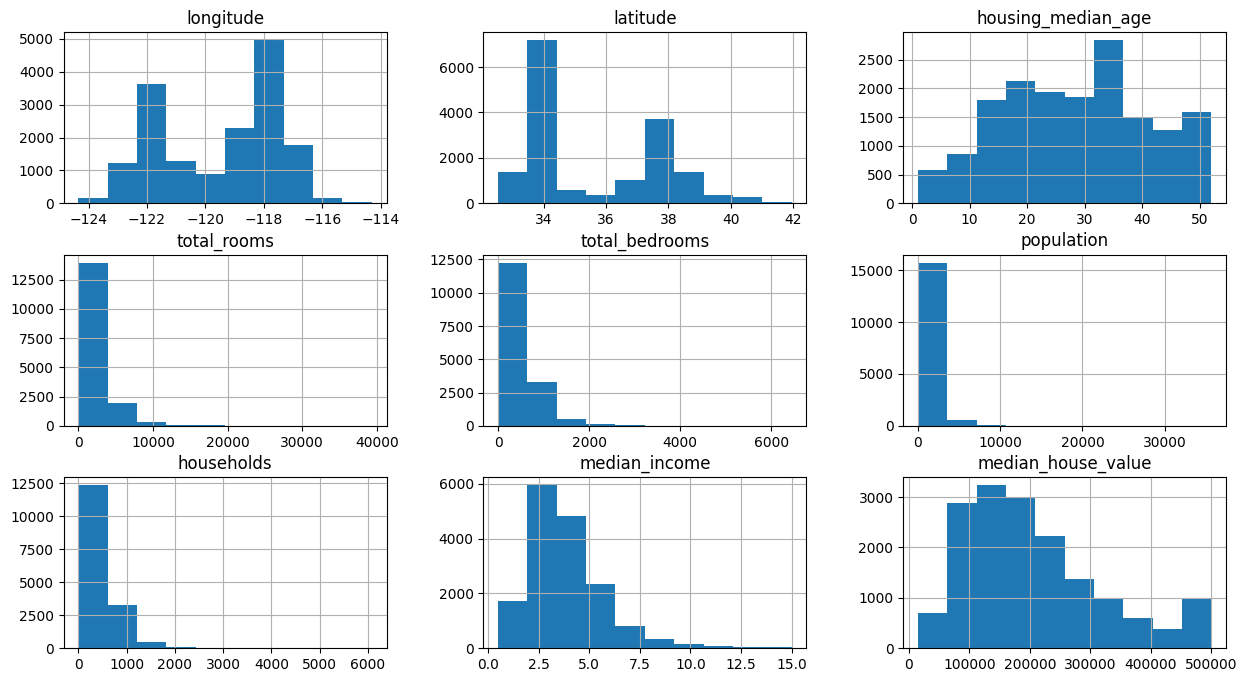

In [88]:
train_data.hist(figsize=(15, 8))

In [89]:
# log transformation of skewed features to make them more normally distributed
col = ['total_rooms', 'total_bedrooms', 'population', 'households']
train_data[col] = train_data[col].apply(lambda x: np.log1p(x)) # log1p is used to avoid log(0) which is undefined
# train_data[col] = train_data[col].apply(lambda x: np.log(x+1))

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

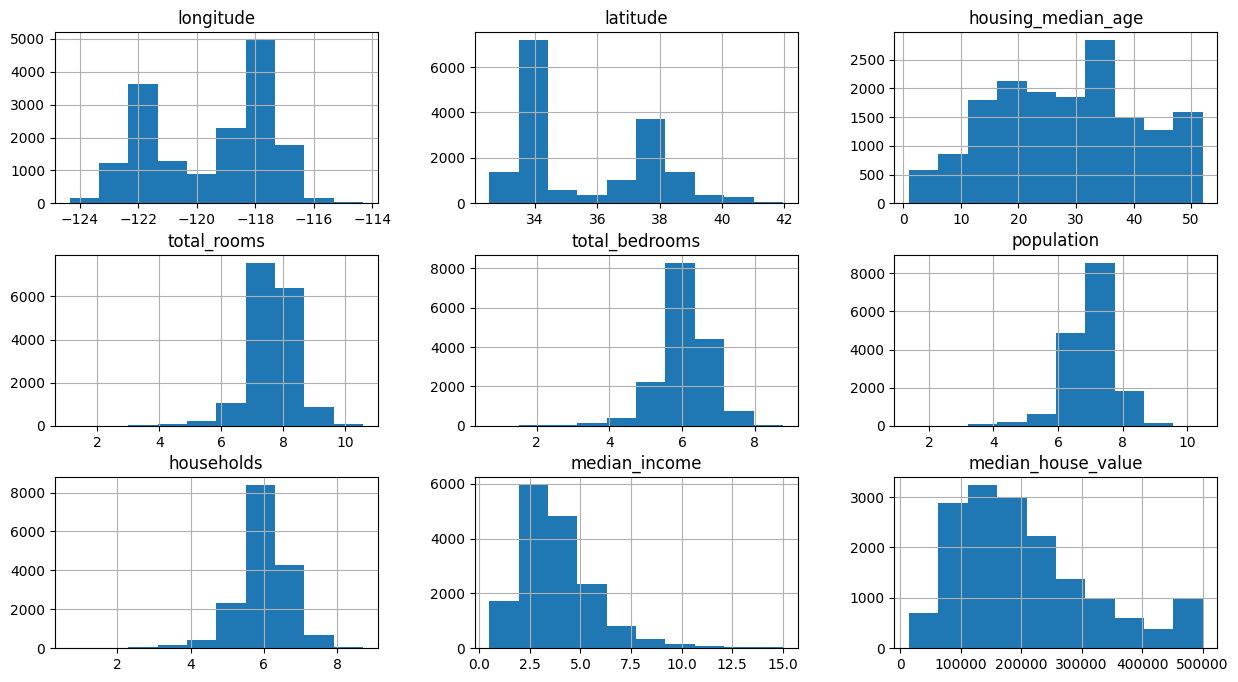

In [90]:
train_data.hist(figsize=(15, 8))

In [91]:
train_data.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924641,-0.115105,0.023927,0.054619,0.103018,0.048402,-0.013082,-0.042526
latitude,-0.924641,1.000000,0.016029,-0.027565,-0.062910,-0.132108,-0.082316,-0.081778,-0.146616
housing_median_age,-0.115105,0.016029,1.000000,-0.313793,-0.273846,-0.243736,-0.241519,-0.113630,0.107148
total_rooms,0.023927,-0.027565,-0.313793,1.000000,0.945365,0.863811,0.930346,0.203770,0.159820
total_bedrooms,0.054619,-0.062910,-0.273846,0.945365,1.000000,0.897273,0.973868,-0.028699,0.053107
population,0.103018,-0.132108,-0.243736,0.863811,0.897273,1.000000,0.933076,-0.010560,-0.023380
households,0.048402,-0.082316,-0.241519,0.930346,0.973868,0.933076,1.000000,0.000445,0.072534
median_income,-0.013082,-0.081778,-0.113630,0.203770,-0.028699,-0.010560,0.000445,1.000000,0.691863
median_house_value,-0.042526,-0.146616,0.107148,0.159820,0.053107,-0.023380,0.072534,0.691863,1.000000


<Axes: >

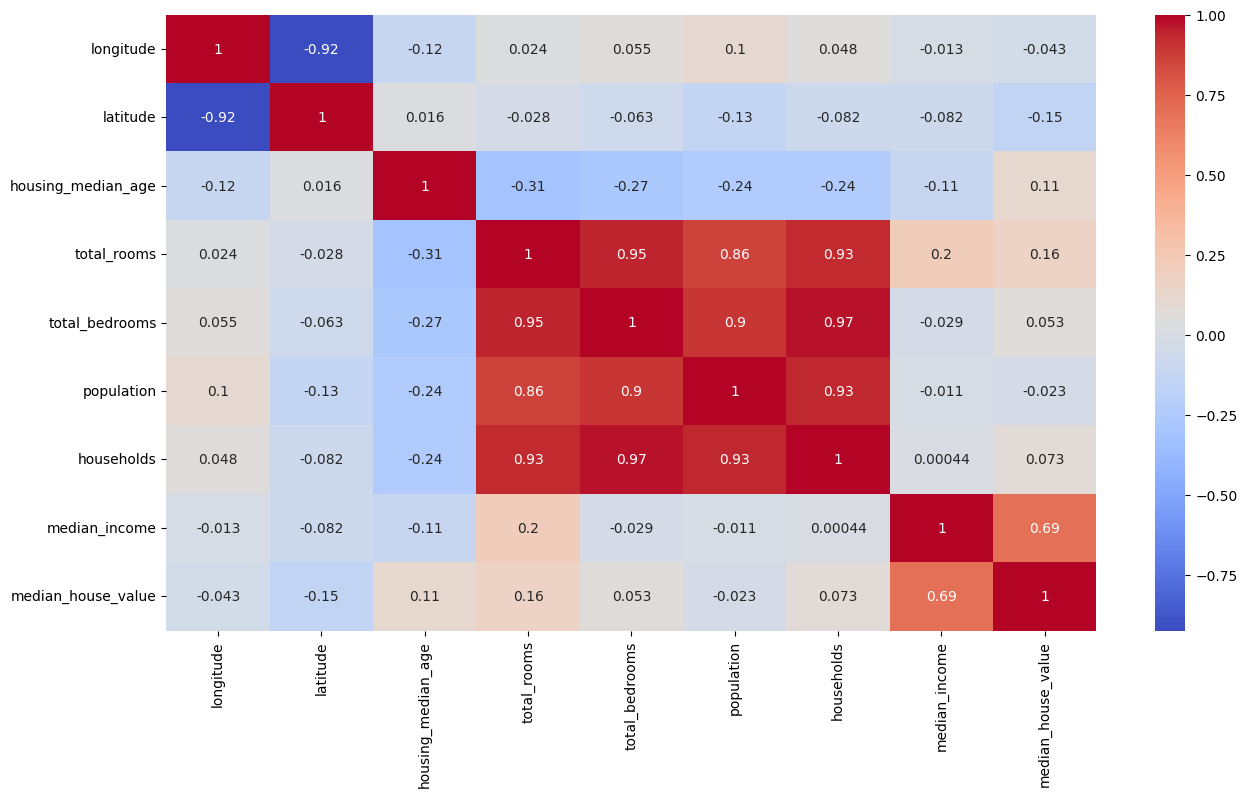

In [92]:
# plt is used to set the figure size, while sns is used to create the heatmap.
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="coolwarm") # annot=True to show correlation values on the heatmap

In [93]:
# check the distribution of the textual feature 'ocean_proximity' in the training set
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7254
INLAND        5185
NEAR OCEAN    2090
NEAR BAY      1815
ISLAND           2
Name: count, dtype: int64

In [94]:
# feature engineering
# create dummy variables for the categorical feature 'ocean_proximity'
train_data = train_data.join(pd.get_dummies(train_data['ocean_proximity'], dtype=int))
# drop the original categorical column
train_data.drop(['ocean_proximity'], axis=1, inplace=True) 

train_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
2518,-122.13,39.74,20.0,7.245655,5.638355,6.505784,5.525453,2.2569,94300.0,0,1,0,0,0
11511,-118.11,33.73,32.0,7.138073,5.811141,6.470800,5.814131,5.0476,500001.0,0,0,0,0,1
8557,-118.40,33.93,35.0,7.704361,6.104793,6.908755,6.111467,4.7319,376100.0,1,0,0,0,0
5778,-118.26,34.15,14.0,8.000349,6.796824,7.571474,6.761573,3.0000,178600.0,1,0,0,0,0
1161,-121.54,39.51,33.0,8.184793,6.630683,7.543273,6.641182,2.5020,62100.0,0,1,0,0,0


<Axes: >

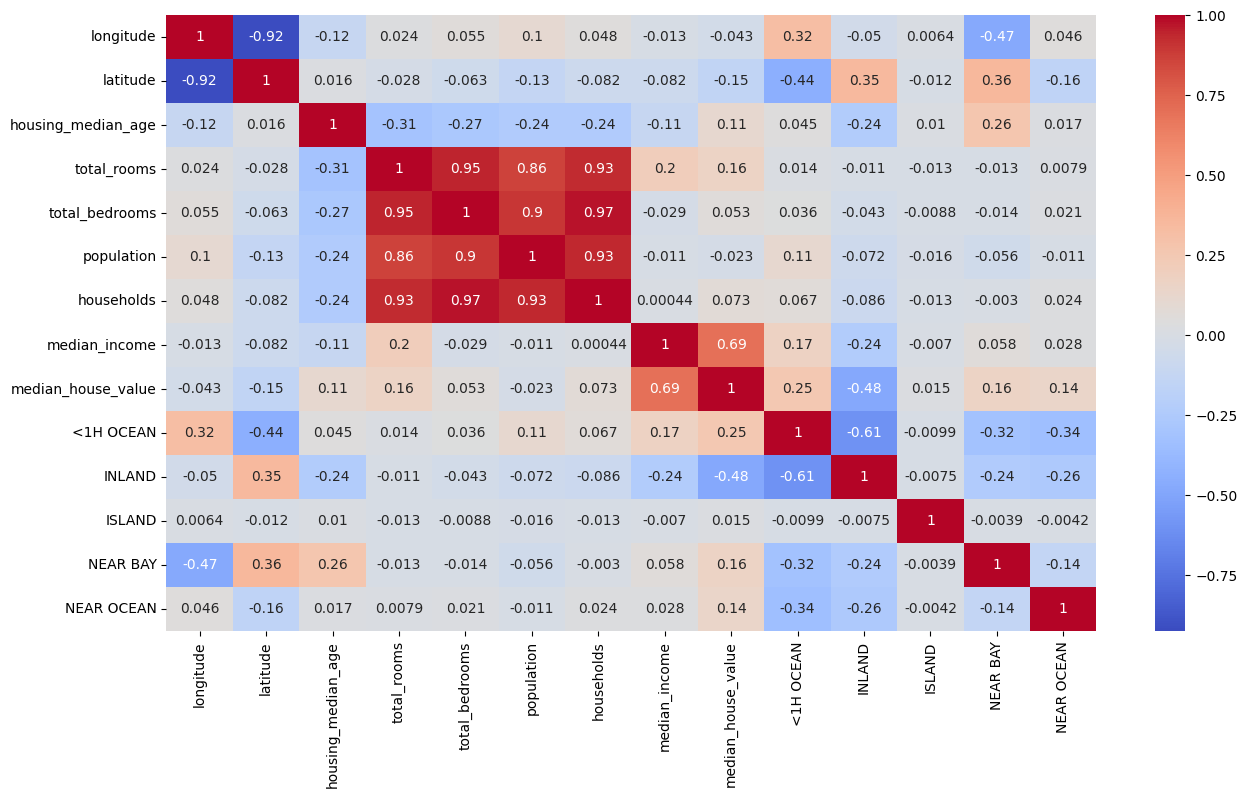

In [95]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True, cmap="coolwarm")

'\nx and y are the coordinates of the points,\ndata is the DataFrame containing the data, \nhue is used to color the points based on a variable\n'

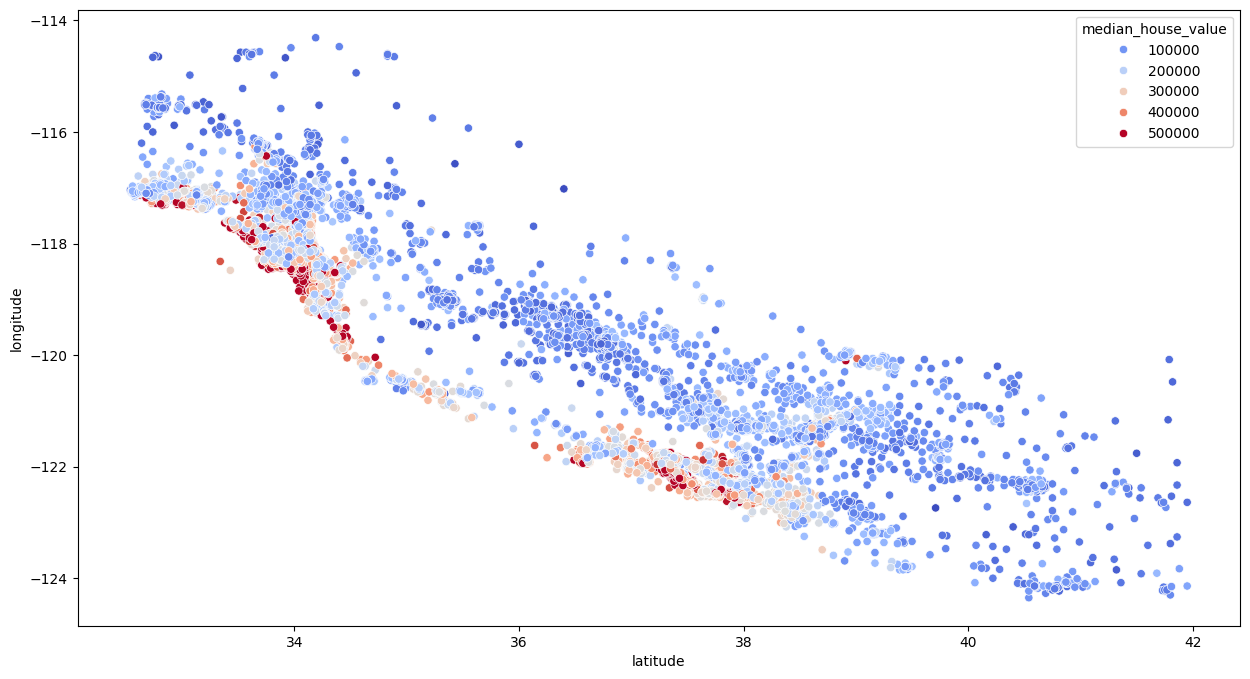

In [96]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x='latitude', y='longitude', data=train_data, hue='median_house_value', palette='coolwarm')
"""
x and y are the coordinates of the points,
data is the DataFrame containing the data, 
hue is used to color the points based on a variable
"""

All the houses closer to the ocean are more expensive.

In [97]:
# feature engineering
# creating new features based on existing ones
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households']

<Axes: >

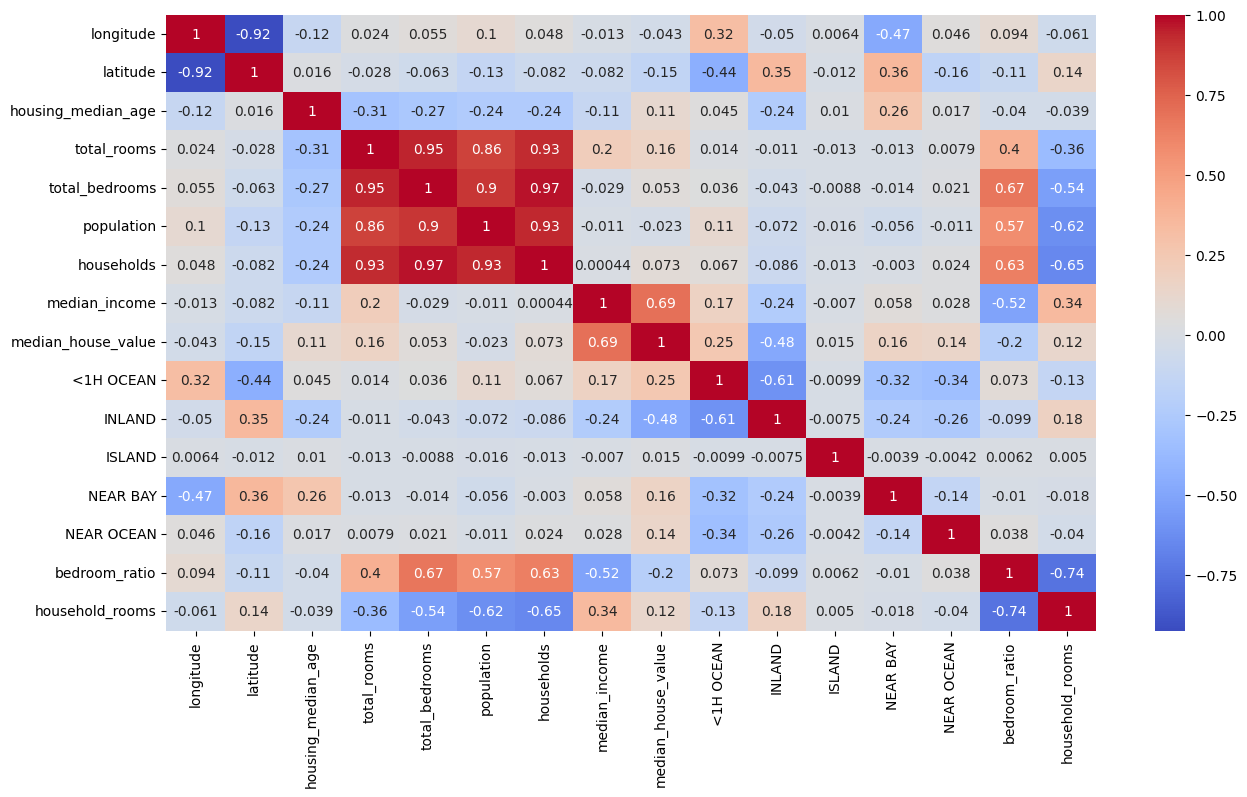

In [98]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True, cmap="coolwarm")

In [99]:
# applying those feature engineering to X_train and y_train
X_train, y_train = train_data.drop(['median_house_value'], axis=1), train_data['median_house_value']

In [100]:
# feature engineering to the test set
test_data = X_test.join(y_test)

# log transformation of skewed features to make them more normally distributed
test_data[col] = test_data[col].apply(lambda x: np.log1p(x)) # log1p is used to avoid log(0) which is undefined

# create dummy variables for the categorical feature 'ocean_proximity'
test_data = test_data.join(pd.get_dummies(test_data['ocean_proximity'], dtype=int))
test_data.drop(['ocean_proximity'], axis=1, inplace=True) 

# creating new features based on existing ones
test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']

X_test, y_test = test_data.drop(['median_house_value'], axis=1), test_data['median_house_value']

In [ ]:
# scaling the features to have mean=0 and variance=1
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [101]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor()
forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [102]:
forest.score(X_test, y_test)

0.8103763179172598

In [103]:
# scaling the features to increase model performance
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # transform the test set using the same scaler fitted on the training set to avoid data leakage

In [106]:
forest = RandomForestRegressor()
forest.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [107]:
forest.score(X_test_scaled, y_test)

0.8086114417718939

The model does not perform better when scaling the features.

In [ ]:
# hyperparameter tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

forest = RandomForestRegressor()

param_grid = {
    'n_estimators': [100, 200, 300],    # number of trees in the forest
    # 'max_features': [None, 10, 20],     # maximum number of features to consider when looking for the best split
    'min_samples_split': [2, 4],        # minimum number of samples required to split an internal node
    'max_depth': [None, 10, 20],        # maximum depth of the tree
}

grid_search = GridSearchCV(forest, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train_scaled, y_train)

KeyboardInterrupt: 

In [110]:
# hyperparameter tuning with RandomizedSearchCV

"""
Instead of exhaustively trying every single combination, RandomizedSearchCV selects a random sample of parameter combinations to evaluate. 
It is mathematically proven to often find hyperparameters that are just as good as a full grid search, but in a fraction of the time.
"""
from sklearn.model_selection import RandomizedSearchCV

forest = RandomForestRegressor()

param_grid = {
    'n_estimators': [100, 200, 300],    # number of trees in the forest
    # 'max_features': [None, 10, 20],     # maximum number of features to consider when looking for the best split
    'min_samples_split': [2, 4],        # minimum number of samples required to split an internal node
    'max_depth': [None, 10, 20],        # maximum depth of the tree
}

random_search = RandomizedSearchCV(
    forest, 
    param_grid, 
    n_iter=8, # only try 8 random combinations instead of all 18
    cv=5, 
    scoring='neg_mean_squared_error', 
    random_state=42, # for reproducibility
    n_jobs=-1 # the magic speed-up parameter
)
random_search.fit(X_train_scaled, y_train)

,estimator,RandomForestRegressor()
,param_distributions,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 4], 'n_estimators': [100, 200, ...]}"
,n_iter,8
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [111]:
random_search.best_estimator_

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [112]:
best_forest = random_search.best_estimator_
best_forest.score(X_test_scaled, y_test)

0.8107009952897625